# Classification with Tensorflow/Keras

In this notebook we will use a simple DNN for classification. We will use the well-known titanic dataset in order to predict passenger survival.

Since you've already worked with the dataset, we'll skip the exploration part and do just a quick and dirty clean up before we start modelling.

## Setup

We'll start as always with importing the necessary libraries and the dataset.

In [2]:
# Import all the libraries I need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# ignore Deprecation Warning
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.utils import plot_model

import keras 
from keras.models import Sequential # intitialize the ANN
from keras.layers import Dense, Activation, Dropout      # create layers

np.random.seed(42)
tf.random.set_seed(42)


# Load dataset
df = pd.read_csv('data/titanic.csv')



## Data Cleaning

Looking at the information about each column and the missing values shows us that we have to clean our data before we can use it for modelling.

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Replace the 2 missings in Embarked with the most common class S

In [7]:
df.Embarked.isnull().sum(axis=0)

2

In [8]:
df.describe(include=['O']) # S is the most common

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [9]:
# fill the NAN
df.Embarked.fillna('S' , inplace=True )

Replace the age based on the median of each Pclass

In [11]:
df.groupby('Pclass').Age.median()

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

In [12]:
# Define function for replacing missing age values based on passenger class 
def age_approx(cols):
    Age = cols[0]
    Pclass = cols[1]
    
    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age
    
    
# Replace missing age values with previously defined function 
df['Age'] = df[['Age', 'Pclass']].apply(age_approx, axis=1)

Drop Cabin due to too many missings

In [13]:
# Let's drop cabin since the majority of entries are missing 
df.drop('Cabin', axis=1, inplace=True)

# We'll also drop the remaining NaN's (2 entries in the Embarked column)
df.dropna(inplace=True)

# Now our dataset is clean (enough)
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Preparation of Features for Model

First we define our features and our label. Then we preprocess our data based on the type (categorical or numeric). 

In [14]:
# Define features and label 
y = df['Survived']
X = df.loc[:,['Age', 'Fare', 'Sex', 'SibSp', 'Parch', 'Pclass', 'Embarked']]

In [15]:
# Let's define our numerical and categorical features
cat_columns = ['Sex', 'SibSp', 'Parch', 'Pclass', 'Embarked']
num_columns = ['Age', 'Fare']

In [16]:
X = pd.get_dummies(X, columns=cat_columns, drop_first=True)

Now we split our data into train- and test-sets.

In [17]:
# Split into train and test set 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state = 42)

In [18]:
scaler = StandardScaler()
X_train[num_columns] = scaler.fit_transform(X_train[num_columns])
X_test[num_columns] = scaler.transform(X_test[num_columns])

In [17]:
X_train.shape

(623, 19)

Up to this point the steps should look familiar to you. But now we will create our very simple Dense Neural Network with: 
- an input layer with 19 nodes  
- a hidden layer with 9 nodes 
- a hidden layer with 9 nodes  
- a dropout layer (The Dropout layer randomly sets input units to 0 with a frequency of rate at each step during training time, which helps prevent overfitting. Inputs not set to 0 are scaled up by 1/(1 - rate) such that the sum over all inputs is unchanged.)
- an output layer which is used to predict a passenger's survival. The output layer has a sigmoid activation function, which is used to 'squash' all our outputs to be between 0 and 1.

We then compile our NN with different hyperparameters like:

1. Optimizers:
While the architecture of the Neural Network plays an important role when extracting information from data, all (most) are being optimized through update rules based on the gradient of the loss function.
The update rules are determined by the Optimizer. The performance and update speed may heavily vary from optimizer to optimizer. The gradient tells us the update direction, but it is still unclear how big of a step we might take. Short steps keep us on track, but it might take a very long time until we reach a (local) minimum. Large steps speed up the process, but it might push us off the right direction.
Adam and RMSProp are two very popular optimizers still being used in most neural networks. Both update the variables using an exponential decaying average of the gradient and its squared. But there are more, have a [look](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers).

2. Loss
Different [loss functions](https://www.tensorflow.org/api_docs/python/tf/keras/losses)

3. Metrics

4. and so on. There are many. Have a look yourself in the [documentary](https://www.tensorflow.org/api_docs/python/tf/keras)

In [19]:
# Initialising the NN
model = Sequential()

# layers
model.add(Dense(units = 9, kernel_initializer = 'uniform', activation = 'relu', input_dim = 19))
model.add(Dense(units = 9, kernel_initializer = 'uniform', activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))

# Compiling the ANN
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
print(model.summary())

2026-06-01 12:23:38.520639: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-01 12:23:38.521110: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Metal device set to: Apple M3

systemMemory: 16.00 GB
maxCacheSize: 5.92 GB

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 9)                 180       
                                                                 
 dense_1 (Dense)             (None, 9)                 90        
                                                                 
 dropout (Dropout)           (None, 9)                 0         
                                                                 
 dense_2 (Dense)             (None, 1)                 10        
                                                                 
Total params: 280
Trainable params: 280
Non-trainable params: 0
_________________________________________________________________
None


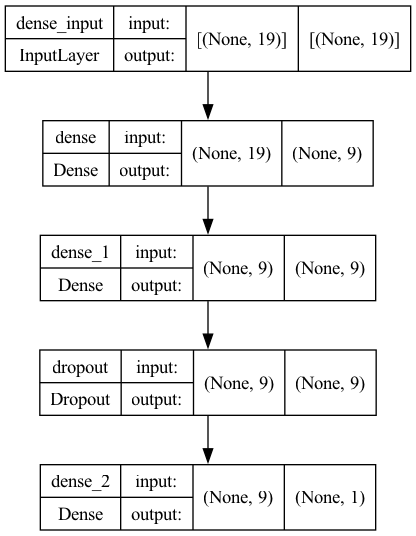

In [20]:
plot_model(
    model, to_file='model.png', show_shapes=True, 
    show_layer_names=True, dpi=96
)

Now we will train our model

Lets have a look at our accuracy at each epoch on the train- and validationset

In [ ]:

print(y_train.dtype)   # should be float32, int32, etc.
print(X_train.shape)
print(y_train.shape)

# Check for NaN or infinite values
import numpy as np
print(np.isnan(X_train).sum())   # should be 0
print(np.isinf(X_train).sum())   # should be 0

In [26]:
import numpy as np

X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)

X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

In [27]:
# Train the ANN
training = model.fit(X_train, y_train, batch_size = 48, validation_split=0.2, epochs = 200)

Epoch 1/200


2026-06-01 12:34:38.755293: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2026-06-01 12:34:39.190311: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


11/11 [==============================] - 3s 53ms/step - loss: 0.6925 - accuracy: 0.6104 - val_loss: 0.6911 - val_accuracy: 0.6640
Epoch 2/200
11/11 [==============================] - 0s 7ms/step - loss: 0.6912 - accuracy: 0.6044 - val_loss: 0.6891 - val_accuracy: 0.6640
Epoch 3/200
 1/11 [=>............................] - ETA: 0s - loss: 0.6912 - accuracy: 0.5625

2026-06-01 12:34:41.552510: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


11/11 [==============================] - 0s 7ms/step - loss: 0.6897 - accuracy: 0.6044 - val_loss: 0.6868 - val_accuracy: 0.6640
Epoch 4/200
11/11 [==============================] - 0s 6ms/step - loss: 0.6877 - accuracy: 0.6044 - val_loss: 0.6841 - val_accuracy: 0.6640
Epoch 5/200
11/11 [==============================] - 0s 6ms/step - loss: 0.6853 - accuracy: 0.6044 - val_loss: 0.6807 - val_accuracy: 0.6640
Epoch 6/200
11/11 [==============================] - 0s 6ms/step - loss: 0.6818 - accuracy: 0.6064 - val_loss: 0.6765 - val_accuracy: 0.6720
Epoch 7/200
11/11 [==============================] - 0s 6ms/step - loss: 0.6772 - accuracy: 0.6185 - val_loss: 0.6711 - val_accuracy: 0.6800
Epoch 8/200
11/11 [==============================] - 0s 6ms/step - loss: 0.6706 - accuracy: 0.6446 - val_loss: 0.6648 - val_accuracy: 0.6960
Epoch 9/200
11/11 [==============================] - 0s 7ms/step - loss: 0.6628 - accuracy: 0.6807 - val_loss: 0.6562 - val_accuracy: 0.7200
Epoch 10/200
11/11 [=====

int64
(623, 19)
(623,)
Age           0
Fare          0
Sex_male      0
SibSp_1       0
SibSp_2       0
SibSp_3       0
SibSp_4       0
SibSp_5       0
SibSp_8       0
Parch_1       0
Parch_2       0
Parch_3       0
Parch_4       0
Parch_5       0
Parch_6       0
Pclass_2      0
Pclass_3      0
Embarked_Q    0
Embarked_S    0
dtype: int64
Age           0
Fare          0
Sex_male      0
SibSp_1       0
SibSp_2       0
SibSp_3       0
SibSp_4       0
SibSp_5       0
SibSp_8       0
Parch_1       0
Parch_2       0
Parch_3       0
Parch_4       0
Parch_5       0
Parch_6       0
Pclass_2      0
Pclass_3      0
Embarked_Q    0
Embarked_S    0
dtype: int64


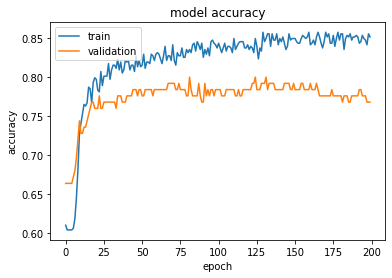

In [28]:
# summarize history for accuracy
plt.plot(training.history['accuracy'])
plt.plot(training.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

And now we will predict the labels for our testset and look at the confusion matrix and the accuracy score.

2026-06-01 12:35:05.759642: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


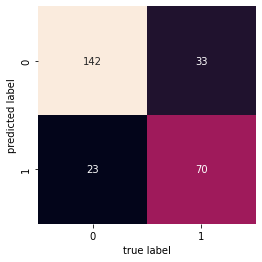

In [29]:
y_pred = model.predict(X_test)

# Plotting the confusing matrix
mat = confusion_matrix(y_test, y_pred.round())
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [30]:
accuracy_score(y_test, y_pred.round()).round(2)

0.79